# Trabajo Práctico 1 – Optimización

**Integrantes:**
- Ana Belén Murillo Solís
- Fabián José Fernández Fernández
- Josué Quintana Serrano

*Link documentacion externa para irla trabajando:* https://www.overleaf.com/9658127568mqmgbmqvhtmv#b3421a

# 2. Importación de librerías

In [ ]:
!pip install optuna


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import optuna

In [ ]:
torch.manual_seed(42)
np.random.seed(42)

# 3. Definición de funciones objetivo

En esta sección se definen las tres funciones del problema y sus gradientes.

In [ ]:
# =========================
# FUNCIONES OBJETIVO
# =========================

def f0(x):
    """
    f0(x, y) = sin(x + y) + (x - y)^2 - 1.5x + 2.5y + 1
    """
    x1, x2 = x[0], x[1]
    return torch.sin(x1 + x2) + (x1 - x2)**2 - 1.5*x1 + 2.5*x2 + 1


def f1(x):
    """
    f1(x, y) = sin^2(3πx) + (x-1)^2(1 + sin^2(3πy)) + (y-1)^2(1 + sin^2(2πy))
    """
    x1, x2 = x[0], x[1]
    term1 = torch.sin(3 * torch.pi * x1)**2
    term2 = (x1 - 1)**2 * (1 + torch.sin(3 * torch.pi * x2)**2)
    term3 = (x2 - 1)**2 * (1 + torch.sin(2 * torch.pi * x2)**2)
    return term1 + term2 + term3


def f2(x):
    """
    f2(x, y) = (x^2 + y - 11)^2 + (x + y^2 - 7)^2
    """
    x1, x2 = x[0], x[1]
    term1 = (x1**2 + x2 - 11)**2
    term2 = (x1 + x2**2 - 7)**2
    return term1 + term2

In [ ]:
# =========================
# GRADIENTES
# =========================

def gradient_f0(x):
    x1, x2 = x[0], x[1]
    df_dx = torch.cos(x1 + x2) + 2*(x1 - x2) - 1.5
    df_dy = torch.cos(x1 + x2) - 2*(x1 - x2) + 2.5
    return torch.tensor([df_dx, df_dy], dtype=torch.float32)


def gradient_f1(x):
    x1, x2 = x[0], x[1]

    df_dx = (
        2 * torch.sin(3 * torch.pi * x1) * torch.cos(3 * torch.pi * x1) * (3 * torch.pi)
        + 2 * (x1 - 1) * (1 + torch.sin(3 * torch.pi * x2)**2)
    )

    df_dy = (
        (x1 - 1)**2 * 2 * torch.sin(3 * torch.pi * x2) * torch.cos(3 * torch.pi * x2) * (3 * torch.pi)
        + 2 * (x2 - 1) * (1 + torch.sin(2 * torch.pi * x2)**2)
        + (x2 - 1)**2 * 2 * torch.sin(2 * torch.pi * x2) * torch.cos(2 * torch.pi * x2) * (2 * torch.pi)
    )

    return torch.tensor([df_dx, df_dy], dtype=torch.float32)


def gradient_f2(x):
    x1, x2 = x[0], x[1]

    df_dx = 2 * (x1**2 + x2 - 11) * (2 * x1) + 2 * (x1 + x2**2 - 7)
    df_dy = 2 * (x1**2 + x2 - 11) + 2 * (x1 + x2**2 - 7) * (2 * x2)

    return torch.tensor([df_dx, df_dy], dtype=torch.float32)

In [ ]:
x_test = torch.tensor([-10.0, 10.0])

print("f0(x_test) =", f0(x_test).item())
print("grad_f0(x_test) =", gradient_f0(x_test))

print("f1(x_test) =", f1(x_test).item())
print("grad_f1(x_test) =", gradient_f1(x_test))

print("f2(x_test) =", f2(x_test).item())
print("grad_f2(x_test) =", gradient_f2(x_test))

f0(x_test) = 441.0
grad_f0(x_test) = tensor([-40.5000,  43.5000])
f1(x_test) = 202.0
grad_f1(x_test) = tensor([-22.0000,  18.0033])
f2(x_test) = 16690.0
grad_f2(x_test) = tensor([-3794.,  3518.])


# 4. Visualización de funciones

En esta sección se generan las gráficas de superficie y curvas de nivel de las funciones objetivo.

### Función auxiliar para graficar

In [ ]:
def plot_function(func, title, x_min=-10, x_max=10, y_min=-10, y_max=10, n_points=200):
    x = np.linspace(x_min, x_max, n_points)
    y = np.linspace(y_min, y_max, n_points)
    X, Y = np.meshgrid(x, y)

    Z = np.zeros_like(X)

    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            point = torch.tensor([X[i, j], Y[i, j]], dtype=torch.float32)
            Z[i, j] = func(point).item()

    # -------- Superficie 3D --------
    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(X, Y, Z, cmap='viridis')
    ax.set_title(f"Superficie 3D - {title}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("f(x,y)")
    plt.show()

    # -------- Contour --------
    plt.figure(figsize=(8, 6))
    contour = plt.contour(X, Y, Z, levels=30)
    plt.clabel(contour, inline=True, fontsize=8)
    plt.title(f"Curvas de nivel - {title}")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid(True)
    plt.show()

## 4.1 Función f0

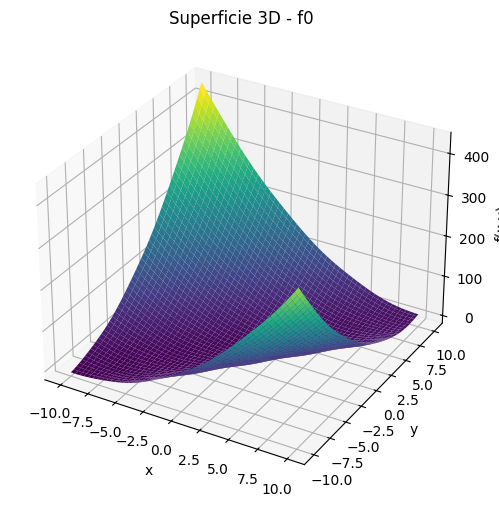

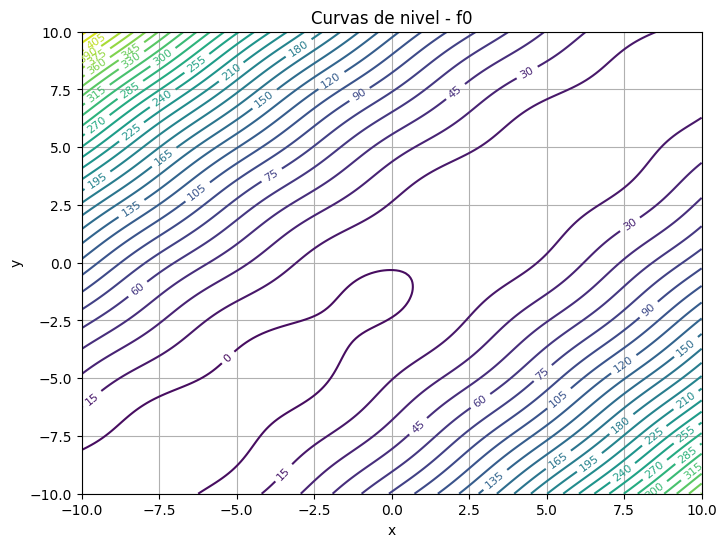

In [ ]:
plot_function(f0, "f0")

## 4.2 Función f1

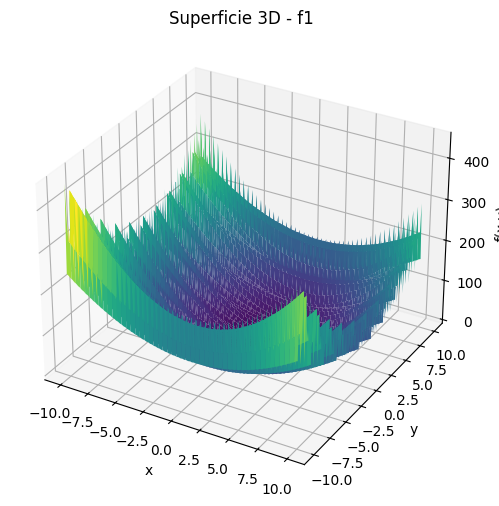

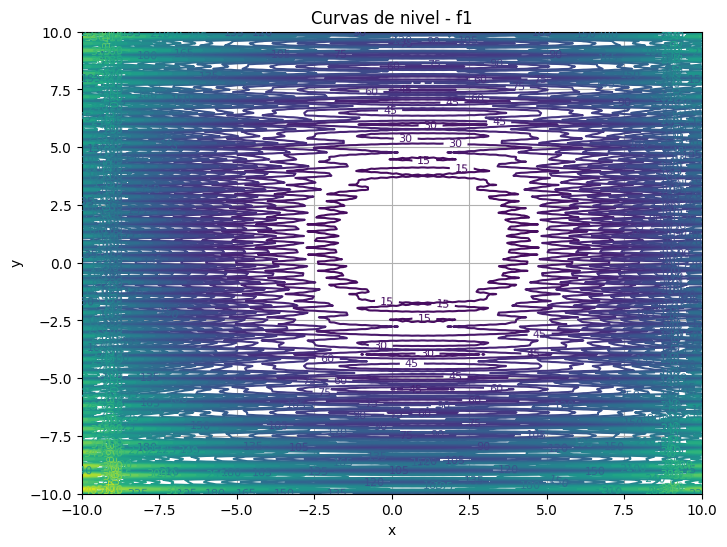

In [ ]:
plot_function(f1, "f1")

## 4.3 Función f2

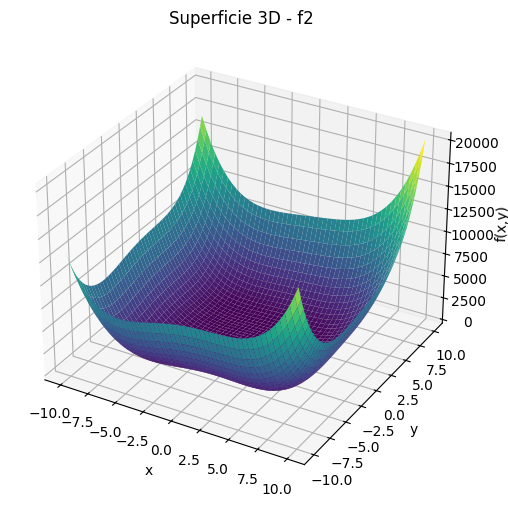

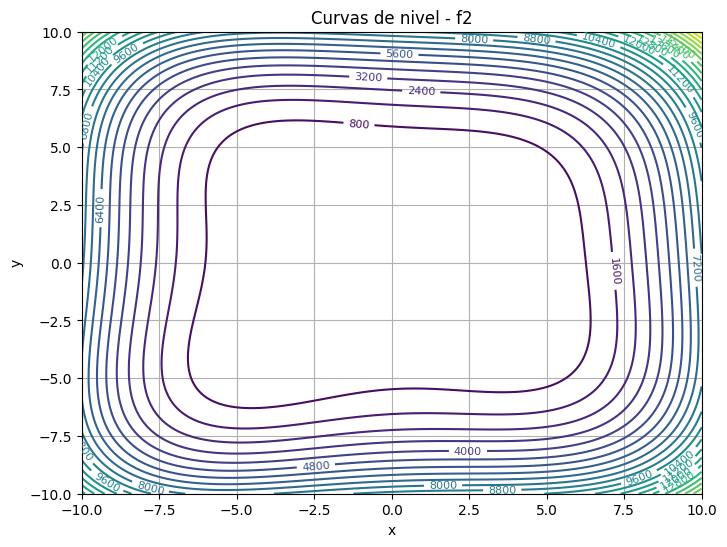

In [ ]:
plot_function(f2, "f2")

# IMPORTANTE ⏰⏰⏰⏰

Aqui falta el analisis de

si la función es convexa o no

los puntos mínimos

regiones o puntos silla

## 5. Implementación de Descenso del Gradiente

En esta sección se implementa el algoritmo de descenso del gradiente para las funciones objetivo.

In [ ]:
def run_gradient_descent(func, grad_func, x0, alpha=0.01, T=25, tol=1e-6):
    """
    Ejecuta descenso del gradiente.

    Parámetros:
    - func: función objetivo
    - grad_func: gradiente de la función
    - x0: punto inicial (tensor de tamaño 2)
    - alpha: learning rate
    - T: número máximo de iteraciones
    - tol: tolerancia para detener si el gradiente es muy pequeño

    Retorna:
    - x_final: punto final
    - f_final: valor final de la función
    - f_history: historial de valores de la función
    - visited: puntos visitados
    - n_iters: número de iteraciones ejecutadas
    """
    x = x0.clone().float()
    f_history = [func(x).item()]
    visited = [x.clone()]

    for t in range(T):
        grad = grad_func(x)

        if torch.norm(grad) < tol:
            break

        x = x - alpha * grad
        visited.append(x.clone())
        f_history.append(func(x).item())

    return {
        "x_final": x,
        "f_final": func(x).item(),
        "f_history": f_history,
        "visited": visited,
        "n_iters": len(f_history) - 1
    }

In [ ]:
x0 = torch.tensor([-10.0, 10.0], dtype=torch.float32)

result_f0_gd = run_gradient_descent(
    func=f0,
    grad_func=gradient_f0,
    x0=x0,
    alpha=0.01,
    T=25
)

print("Punto final:", result_f0_gd["x_final"])
print("Valor final:", result_f0_gd["f_final"])
print("Iteraciones:", result_f0_gd["n_iters"])

Punto final: tensor([-3.6390,  2.9294])
Valor final: 56.27326965332031
Iteraciones: 25


In [ ]:
result_f1_gd = run_gradient_descent(
    func=f1,
    grad_func=gradient_f1,
    x0=x0,
    alpha=0.001,
    T=25
)

print("Punto final:", result_f1_gd["x_final"])
print("Valor final:", result_f1_gd["f_final"])
print("Iteraciones:", result_f1_gd["n_iters"])

Punto final: tensor([-9.2008, 11.3215])
Valor final: 299.1972351074219
Iteraciones: 25


In [ ]:
result_f2_gd = run_gradient_descent(
    func=f2,
    grad_func=gradient_f2,
    x0=x0,
    alpha=0.001,
    T=25
)

print("Punto final:", result_f2_gd["x_final"])
print("Valor final:", result_f2_gd["f_final"])
print("Iteraciones:", result_f2_gd["n_iters"])

Punto final: tensor([-3.0392,  3.3015])
Valor final: 3.106809139251709
Iteraciones: 25


In [ ]:
def plot_learning_curve(f_history, title="Curva de aprendizaje"):
    plt.figure(figsize=(8, 5))
    plt.plot(f_history, marker='o')
    plt.xlabel("Iteración")
    plt.ylabel("f(x)")
    plt.title(title)
    plt.grid(True)
    plt.show()

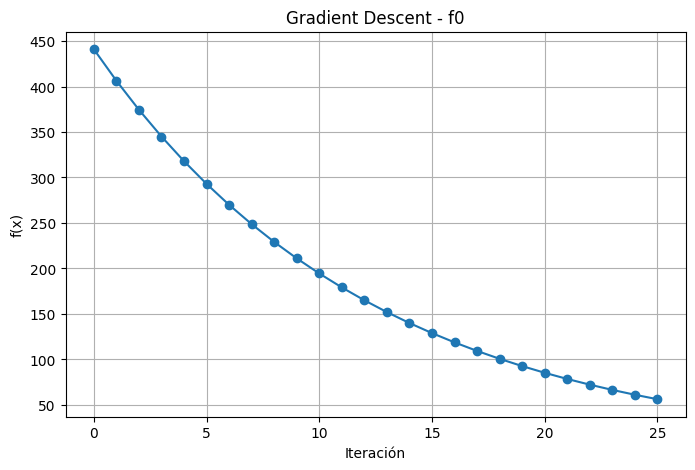

In [ ]:
plot_learning_curve(result_f0_gd["f_history"], "Gradient Descent - f0")


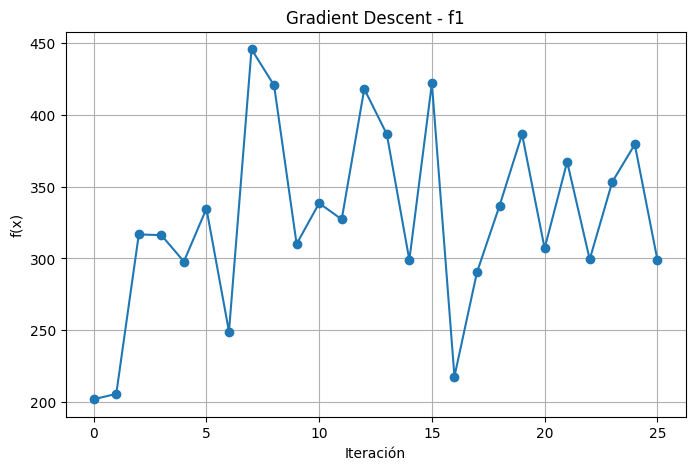

In [ ]:
plot_learning_curve(result_f1_gd["f_history"], "Gradient Descent - f1")

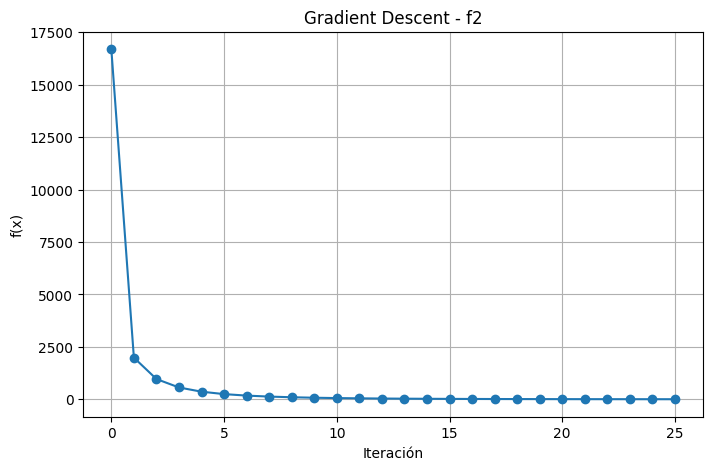

In [ ]:
plot_learning_curve(result_f2_gd["f_history"], "Gradient Descent - f2")

# 6. Calibración de alpha con Optuna para Gradient Descent

En esta sección se calibra el hiperparámetro `alpha` del algoritmo de descenso del gradiente para cada función objetivo.

# 6.1 Optuna para f0

In [ ]:
def random_point(low=-10.0, high=10.0):
    return torch.empty(2).uniform_(low, high)

In [ ]:
def objective_gd_f0(trial):
    alpha = trial.suggest_float("alpha", 1e-4, 1.0, log=True)
    x0 = random_point()

    result = run_gradient_descent(
        func=f0,
        grad_func=gradient_f0,
        x0=x0,
        alpha=alpha,
        T=25
    )

    return result["f_final"]

In [ ]:
study_gd_f0 = optuna.create_study(direction="minimize")
study_gd_f0.optimize(objective_gd_f0, n_trials=50, show_progress_bar=True)

[I 2026-03-12 21:26:56,664] A new study created in memory with name: no-name-35331f3f-6d12-47f9-84ca-d5b8b83c8c7a


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-03-12 21:26:56,695] Trial 0 finished with value: 1.2016096115112305 and parameters: {'alpha': 0.018652171109613952}. Best is trial 0 with value: 1.2016096115112305.
[I 2026-03-12 21:26:56,705] Trial 1 finished with value: -8.19640064239502 and parameters: {'alpha': 0.43271517074566507}. Best is trial 1 with value: -8.19640064239502.
[I 2026-03-12 21:26:56,720] Trial 2 finished with value: 4842189824.0 and parameters: {'alpha': 0.6146458663411823}. Best is trial 1 with value: -8.19640064239502.
[I 2026-03-12 21:26:56,737] Trial 3 finished with value: 1.3841924667358398 and parameters: {'alpha': 0.008032413205598124}. Best is trial 1 with value: -8.19640064239502.
[I 2026-03-12 21:26:56,750] Trial 4 finished with value: 7.511600494384766 and parameters: {'alpha': 0.08035801552264127}. Best is trial 1 with value: -8.19640064239502.
[I 2026-03-12 21:26:56,763] Trial 5 finished with value: 124.45991516113281 and parameters: {'alpha': 0.0001804656418819413}. Best is trial 1 with valu

In [ ]:
print("Mejor alpha para f0:", study_gd_f0.best_params["alpha"])
print("Mejor valor encontrado para f0:", study_gd_f0.best_value)

Mejor alpha para f0: 0.39859493123750117
Mejor valor encontrado para f0: -8.196409225463867


## 6.2 Optuna para f1

In [ ]:
def objective_gd_f1(trial):
    alpha = trial.suggest_float("alpha", 1e-5, 1.0, log=True)
    x0 = random_point()

    result = run_gradient_descent(
        func=f1,
        grad_func=gradient_f1,
        x0=x0,
        alpha=alpha,
        T=25
    )

    return result["f_final"]

In [ ]:
study_gd_f1 = optuna.create_study(direction="minimize")
study_gd_f1.optimize(objective_gd_f1, n_trials=50, show_progress_bar=True)

[I 2026-03-12 21:23:45,123] A new study created in memory with name: no-name-57a19f65-ad81-43fa-a799-db98b78f1d9f


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-03-12 21:23:45,206] Trial 0 finished with value: 47.553260803222656 and parameters: {'alpha': 0.00011580725221088112}. Best is trial 0 with value: 47.553260803222656.
[I 2026-03-12 21:23:45,231] Trial 1 finished with value: 79.50865936279297 and parameters: {'alpha': 0.0010161835701223768}. Best is trial 0 with value: 47.553260803222656.
[W 2026-03-12 21:23:45,260] Trial 2 failed with parameters: {'alpha': 0.039875704013359305} because of the following error: The value nan is not acceptable.
[W 2026-03-12 21:23:45,262] Trial 2 failed with value nan.
[W 2026-03-12 21:23:45,288] Trial 3 failed with parameters: {'alpha': 0.037402980315145655} because of the following error: The value nan is not acceptable.
[W 2026-03-12 21:23:45,292] Trial 3 failed with value nan.
[I 2026-03-12 21:23:45,316] Trial 4 finished with value: 186.56976318359375 and parameters: {'alpha': 3.4891364872653665e-05}. Best is trial 0 with value: 47.553260803222656.
[I 2026-03-12 21:23:45,342] Trial 5 finished 

In [ ]:
print("Mejor alpha para f1:", study_gd_f1.best_params["alpha"])
print("Mejor valor encontrado para f1:", study_gd_f1.best_value)

Mejor alpha para f1: 0.03623389531166918
Mejor valor encontrado para f1: 2.4481518268585205


## 6.3 Optuna para f2

In [ ]:
def objective_gd_f2(trial):
    alpha = trial.suggest_float("alpha", 1e-5, 1.0, log=True)
    x0 = random_point()

    result = run_gradient_descent(
        func=f2,
        grad_func=gradient_f2,
        x0=x0,
        alpha=alpha,
        T=25
    )

    return result["f_final"]

In [ ]:
study_gd_f2 = optuna.create_study(direction="minimize")
study_gd_f2.optimize(objective_gd_f2, n_trials=50, show_progress_bar=True)

[I 2026-03-12 21:27:27,193] A new study created in memory with name: no-name-03247ca4-b73a-4511-823a-3fe457a443a5


  0%|          | 0/50 [00:00<?, ?it/s]

[W 2026-03-12 21:27:27,224] Trial 0 failed with parameters: {'alpha': 0.3300458031087386} because of the following error: The value nan is not acceptable.
[W 2026-03-12 21:27:27,226] Trial 0 failed with value nan.
[I 2026-03-12 21:27:27,235] Trial 1 finished with value: 2.2612922191619873 and parameters: {'alpha': 0.0009812298142147613}. Best is trial 1 with value: 2.2612922191619873.
[W 2026-03-12 21:27:27,250] Trial 2 failed with parameters: {'alpha': 0.47771986519392806} because of the following error: The value nan is not acceptable.
[W 2026-03-12 21:27:27,252] Trial 2 failed with value nan.
[I 2026-03-12 21:27:27,264] Trial 3 finished with value: 57.601051330566406 and parameters: {'alpha': 0.00014276449164953565}. Best is trial 1 with value: 2.2612922191619873.
[W 2026-03-12 21:27:27,276] Trial 4 failed with parameters: {'alpha': 0.47852265419404233} because of the following error: The value nan is not acceptable.
[W 2026-03-12 21:27:27,277] Trial 4 failed with value nan.
[I 2026

In [ ]:
best_alpha_f0 = study_gd_f0.best_params["alpha"]
best_alpha_f1 = study_gd_f1.best_params["alpha"]
best_alpha_f2 = study_gd_f2.best_params["alpha"]

print("best_alpha_f0 =", best_alpha_f0)
print("best_alpha_f1 =", best_alpha_f1)
print("best_alpha_f2 =", best_alpha_f2)

best_alpha_f0 = 0.24197949662726898
best_alpha_f1 = 0.03623389531166918
best_alpha_f2 = 0.01761260140846948


In [ ]:
def plot_optuna_history(study, title="Historial de optimización"):
    values = [trial.value for trial in study.trials if trial.value is not None]

    plt.figure(figsize=(8, 5))
    plt.plot(values, marker='o')
    plt.xlabel("Trial")
    plt.ylabel("Valor objetivo")
    plt.title(title)
    plt.grid(True)
    plt.show()

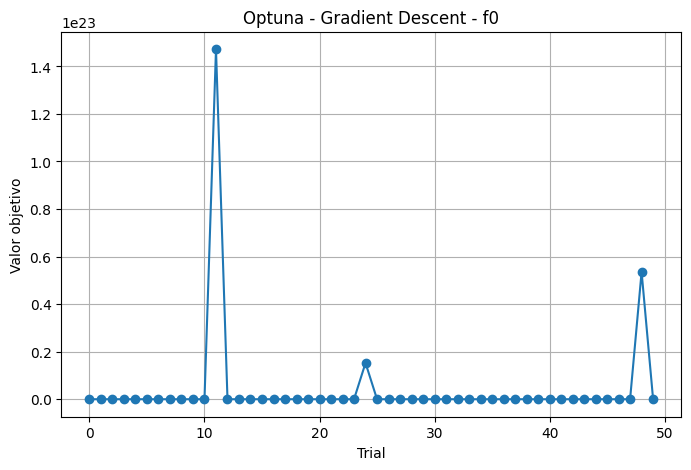

In [ ]:
plot_optuna_history(study_gd_f0, "Optuna - Gradient Descent - f0")


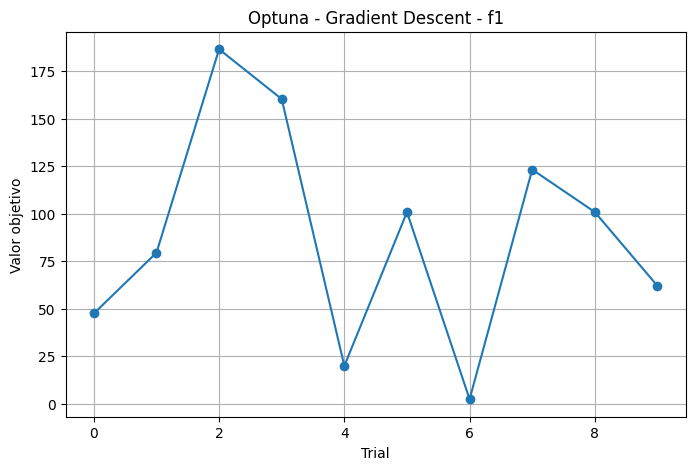

In [ ]:
plot_optuna_history(study_gd_f1, "Optuna - Gradient Descent - f1")


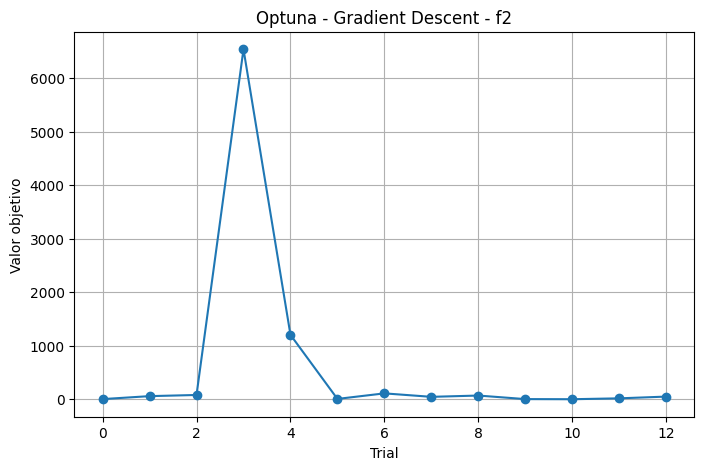

In [ ]:
plot_optuna_history(study_gd_f2, "Optuna - Gradient Descent - f2")

# 7. Experimentos finales de Gradient Descent

En esta sección se ejecuta el algoritmo de descenso del gradiente utilizando los mejores valores de `alpha` encontrados previamente. Para cada función se realizan 10 corridas con distintos puntos iniciales.

In [ ]:
def generate_initial_points(n_points=10, low=-10.0, high=10.0, seed=42):
    torch.manual_seed(seed)
    points = [torch.empty(2).uniform_(low, high) for _ in range(n_points)]
    return points

In [ ]:
initial_points = generate_initial_points(n_points=10)

for i, p in enumerate(initial_points):
    print(f"Punto inicial {i+1}: {p}")

Punto inicial 1: tensor([7.6454, 8.3001])
Punto inicial 2: tensor([-2.3427,  9.1861])
Punto inicial 3: tensor([-2.1910,  2.0179])
Punto inicial 4: tensor([-4.8686,  5.8728])
Punto inicial 5: tensor([ 8.8154, -7.3363])
Punto inicial 6: tensor([8.6920, 1.8716])
Punto inicial 7: tensor([7.3881, 1.3543])
Punto inicial 8: tensor([ 4.8219, -1.4119])
Punto inicial 9: tensor([7.7089, 1.4781])
Punto inicial 10: tensor([-4.6684,  2.5490])


In [ ]:
def run_multiple_experiments_gd(func, grad_func, alpha, initial_points, T=50):
    results = []

    for i, x0 in enumerate(initial_points):
        result = run_gradient_descent(
            func=func,
            grad_func=grad_func,
            x0=x0,
            alpha=alpha,
            T=T
        )

        results.append({
            "corrida": i + 1,
            "x0": x0.tolist(),
            "x_final": result["x_final"].tolist(),
            "f_final": result["f_final"],
            "iteraciones": result["n_iters"]
        })

    return results

## 7.1 Resultados GD en f0

In [ ]:
results_gd_f0 = run_multiple_experiments_gd(
    func=f0,
    grad_func=gradient_f0,
    alpha=best_alpha_f0,
    initial_points=initial_points,
    T=50
)

## 7.2 Resultados GD en f1

In [ ]:
results_gd_f1 = run_multiple_experiments_gd(
    func=f1,
    grad_func=gradient_f1,
    alpha=best_alpha_f1,
    initial_points=initial_points,
    T=50
)

## 7.3 Resultados GD en f2

In [ ]:
results_gd_f2 = run_multiple_experiments_gd(
    func=f2,
    grad_func=gradient_f2,
    alpha=best_alpha_f2,
    initial_points=initial_points,
    T=50
)

In [ ]:
def print_results_table(results, title="Resultados"):
    print(f"\n{title}")
    print("-" * 120)
    print(f"{'Corrida':<10}{'x0':<30}{'x_final':<35}{'f_final':<20}{'Iteraciones':<15}")
    print("-" * 120)

    for r in results:
        print(f"{r['corrida']:<10}{str(r['x0']):<30}{str(r['x_final']):<35}{r['f_final']:<20.6f}{r['iteraciones']:<15}")

In [ ]:
print_results_table(results_gd_f0, "Gradient Descent - f0")
print_results_table(results_gd_f1, "Gradient Descent - f1")
print_results_table(results_gd_f2, "Gradient Descent - f2")


Gradient Descent - f0
------------------------------------------------------------------------------------------------------------------------
Corrida   x0                            x_final                            f_final             Iteraciones    
------------------------------------------------------------------------------------------------------------------------
1         [7.645385265350342, 8.300079345703125][8.877580642700195, 7.877580165863037]7.511555            50             
2         [-2.3427248001098633, 9.186113357543945][2.594395399093628, 1.5943955183029175]1.228370            28             
3         [-2.191035747528076, 2.017906904220581][-0.5471972227096558, -1.5471972227096558]-1.913223           27             
4         [-4.8685503005981445, 5.87282657623291][-0.5471972227096558, -1.5471972227096558]-1.913223           29             
5         [8.8154296875, -7.336281776428223][-0.5471972823143005, -1.5471972227096558]-1.913223           31             
6

In [ ]:
def get_best_run(results):
    return min(results, key=lambda r: r["f_final"])

In [ ]:
best_run_gd_f0 = get_best_run(results_gd_f0)
best_run_gd_f1 = get_best_run(results_gd_f1)
best_run_gd_f2 = get_best_run(results_gd_f2)

print("Mejor corrida GD f0:", best_run_gd_f0)
print("Mejor corrida GD f1:", best_run_gd_f1)
print("Mejor corrida GD f2:", best_run_gd_f2)

Mejor corrida GD f0: {'corrida': 3, 'x0': [-2.191035747528076, 2.017906904220581], 'x_final': [-0.5471972227096558, -1.5471972227096558], 'f_final': -1.9132230281829834, 'iteraciones': 27}
Mejor corrida GD f1: {'corrida': 1, 'x0': [7.645385265350342, 8.300079345703125], 'x_final': [nan, nan], 'f_final': nan, 'iteraciones': 50}
Mejor corrida GD f2: {'corrida': 1, 'x0': [7.645385265350342, 8.300079345703125], 'x_final': [nan, nan], 'f_final': nan, 'iteraciones': 50}


In [ ]:
def summarize_results(results):
    f_values = [r["f_final"] for r in results]
    iters = [r["iteraciones"] for r in results]

    return {
        "promedio_f_final": np.mean(f_values),
        "std_f_final": np.std(f_values),
        "promedio_iteraciones": np.mean(iters)
    }

In [ ]:
summary_gd_f0 = summarize_results(results_gd_f0)
summary_gd_f1 = summarize_results(results_gd_f1)
summary_gd_f2 = summarize_results(results_gd_f2)

print("Resumen GD f0:", summary_gd_f0)
print("Resumen GD f1:", summary_gd_f1)
print("Resumen GD f2:", summary_gd_f2)

Resumen GD f0: {'promedio_f_final': np.float64(1.5425288200378418), 'std_f_final': np.float64(3.2799189246922094), 'promedio_iteraciones': np.float64(36.3)}
Resumen GD f1: {'promedio_f_final': np.float64(nan), 'std_f_final': np.float64(nan), 'promedio_iteraciones': np.float64(50.0)}
Resumen GD f2: {'promedio_f_final': np.float64(nan), 'std_f_final': np.float64(nan), 'promedio_iteraciones': np.float64(50.0)}


En esta sección se presentan los resultados del algoritmo de descenso del gradiente utilizando los mejores valores de `alpha` obtenidos mediante Optuna. Se ejecutaron 10 corridas por función, preservando los mismos puntos iniciales para facilitar comparaciones posteriores con otros algoritmos.

# 8. Trayectoria y curva de aprendizaje de GD

En esta sección se visualiza la trayectoria seguida por el algoritmo de descenso del gradiente sobre las curvas de nivel de cada función, así como su curva de aprendizaje para la mejor corrida.

In [ ]:
def rerun_best_experiment(func, grad_func, alpha, best_run, T=50):
    x0 = torch.tensor(best_run["x0"], dtype=torch.float32)

    result = run_gradient_descent(
        func=func,
        grad_func=grad_func,
        x0=x0,
        alpha=alpha,
        T=T
    )

    return result

In [ ]:
best_result_gd_f0 = rerun_best_experiment(
    func=f0,
    grad_func=gradient_f0,
    alpha=best_alpha_f0,
    best_run=best_run_gd_f0,
    T=50
)

best_result_gd_f1 = rerun_best_experiment(
    func=f1,
    grad_func=gradient_f1,
    alpha=best_alpha_f1,
    best_run=best_run_gd_f1,
    T=50
)

best_result_gd_f2 = rerun_best_experiment(
    func=f2,
    grad_func=gradient_f2,
    alpha=best_alpha_f2,
    best_run=best_run_gd_f2,
    T=50
)

In [ ]:
def plot_trajectory_on_contour(func, visited, title, x_min=-10, x_max=10, y_min=-10, y_max=10, n_points=200):
    x = np.linspace(x_min, x_max, n_points)
    y = np.linspace(y_min, y_max, n_points)
    X, Y = np.meshgrid(x, y)

    Z = np.zeros_like(X)

    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            point = torch.tensor([X[i, j], Y[i, j]], dtype=torch.float32)
            Z[i, j] = func(point).item()

    xs = [p[0].item() for p in visited]
    ys = [p[1].item() for p in visited]

    plt.figure(figsize=(8, 6))
    contour = plt.contour(X, Y, Z, levels=30)
    plt.clabel(contour, inline=True, fontsize=8)

    plt.plot(xs, ys, marker='o', color='red')
    plt.scatter(xs[0], ys[0], marker='s', s=100, label='Inicio')
    plt.scatter(xs[-1], ys[-1], marker='*', s=150, label='Final')

    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.grid(True)
    plt.show()

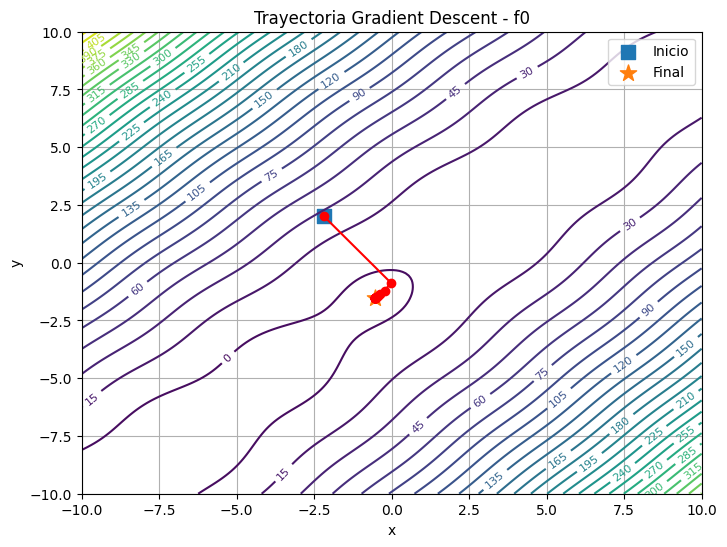

In [ ]:
plot_trajectory_on_contour(
    func=f0,
    visited=best_result_gd_f0["visited"],
    title="Trayectoria Gradient Descent - f0"
)

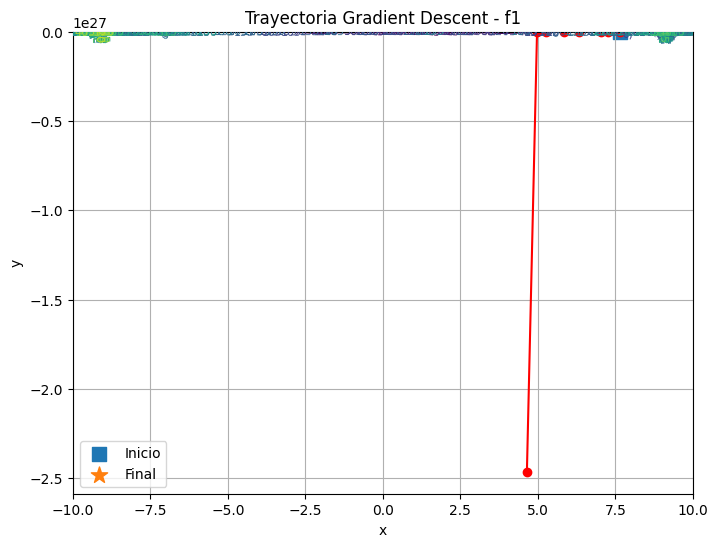

In [ ]:
plot_trajectory_on_contour(
    func=f1,
    visited=best_result_gd_f1["visited"],
    title="Trayectoria Gradient Descent - f1"
)

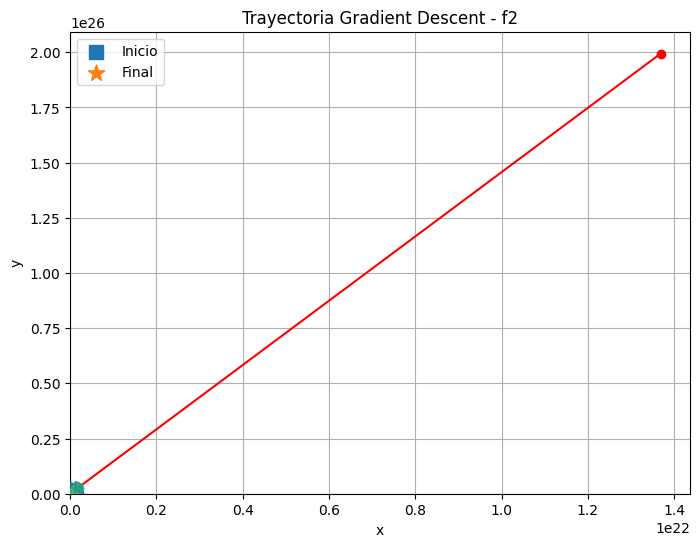

In [ ]:
plot_trajectory_on_contour(
    func=f2,
    visited=best_result_gd_f2["visited"],
    title="Trayectoria Gradient Descent - f2"
)

In [ ]:
def plot_learning_curve(f_history, title):
    plt.figure(figsize=(8, 5))
    plt.plot(f_history, marker='o')
    plt.xlabel("Iteración")
    plt.ylabel("Valor de la función")
    plt.title(title)
    plt.grid(True)
    plt.show()

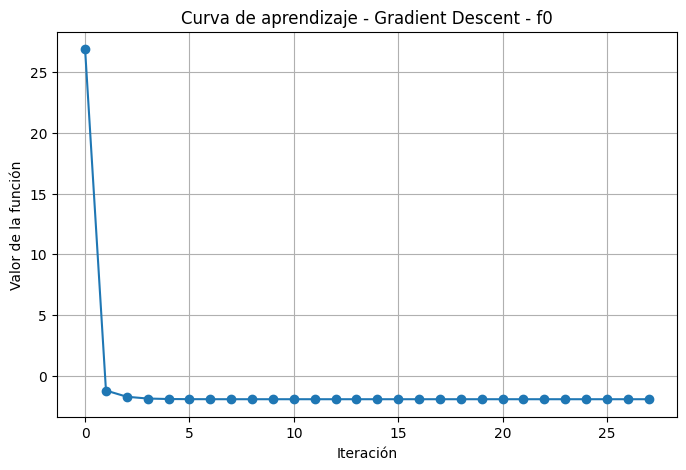

In [ ]:
plot_learning_curve(
    best_result_gd_f0["f_history"],
    "Curva de aprendizaje - Gradient Descent - f0"
)


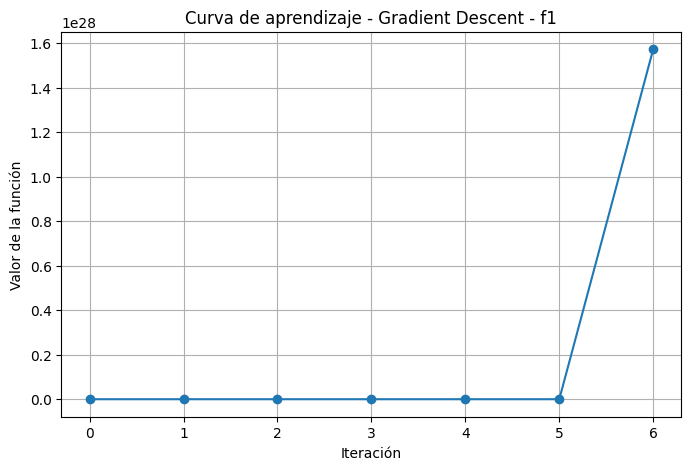

In [ ]:
plot_learning_curve(
    best_result_gd_f1["f_history"],
    "Curva de aprendizaje - Gradient Descent - f1"
)

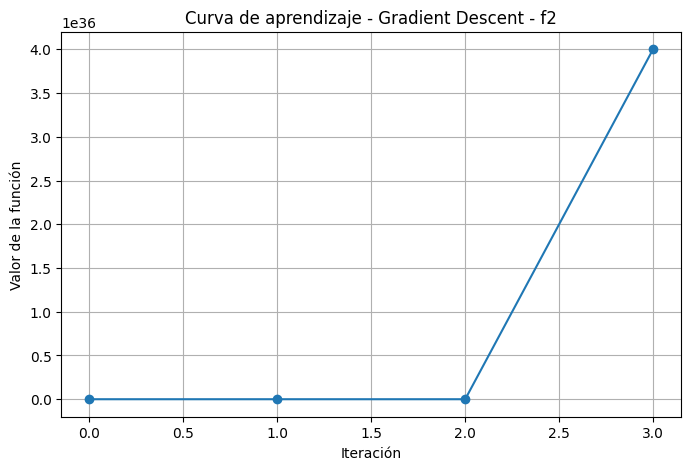

In [ ]:
plot_learning_curve(
    best_result_gd_f2["f_history"],
    "Curva de aprendizaje - Gradient Descent - f2"
)

## 8.1 Mejor corrida GD en f0

## 8.2 Mejor corrida GD en f1

## 8.3 Mejor corrida GD en f2

# 9. Implementación de RMSProp

# 10. Calibración de hiperparámetros con Optuna para RMSProp

## 10.1 Optuna RMSProp para f0

## 10.2 Optuna RMSProp para f1

## 10.3 Optuna RMSProp para f2

# 11. Experimentos finales de RMSProp

## 11.1 Resultados RMSProp en f0

## 11.2 Resultados RMSProp en f1

## 11.3 Resultados RMSProp en f2

# 12. Trayectoria y curva de aprendizaje de RMSProp

## 12.1 Mejor corrida RMSProp en f0

## 12.2 Mejor corrida RMSProp en f1

## 12.3 Mejor corrida RMSProp en f2

# 13. Comparación: GD vs RMSProp

# 14. Implementación de CMA-ES

# 15. Calibración de hiperparámetros con Optuna para CMA-ES

## 15.1 Optuna CMA-ES para f0

## 15.2 Optuna CMA-ES para f1

## 15.3 Optuna CMA-ES para f2

# 16. Experimentos finales de CMA-ES

## 16.1 Resultados CMA-ES en f0

## 16.2 Resultados CMA-ES en f1

## 16.3 Resultados CMA-ES en f2

# 17. Trayectoria y curva de aprendizaje de CMA-ES

## 17.1 Mejor corrida CMA-ES en f0

## 17.2 Mejor corrida CMA-ES en f1

## 17.3 Mejor corrida CMA-ES en f2

# 18. Mezcla entre GD y CMA-ES

# 19. Comparación final entre todos los algoritmos

# 20. Conclusiones

# 21. Pruebas unitarias